# Análisis Exploratorio de Datos (EDA) — Empleo en plantas de proceso de pesca

**Objetivo.** Explorar y entender la estructura, calidad y patrones del dataset de empleo en plantas de proceso de pesca para informar el preprocesamiento y el modelado posterior. Nos enfocamos en:
- **Variable objetivo:** `Categoría` (p.ej., CONTRATO vs SUB‑CONTRATO).
- **Variable numérica clave:** `Ocupados` (número de trabajadores).
- **Cortes temporales:** `AÑO`, `Trimestre`, `Mes`.
- **Dimensión laboral:** `Función` (p.ej., Administrativos, Directivos, Productivos_Directos, etc.).

---

## Alcance del EDA
1. **Estructura y calidad**
   - Tipos de datos, dimensiones.
   - **Valores nulos** y **duplicados** por columna; decisiones: conservar / imputar / eliminar.
2. **Variable objetivo**
   - Distribución y **balanceo** de clases.
   - Coherencia de etiquetas (normalización y categorías “raras”).
3. **Variables numéricas (`Ocupados`)**
   - Resumen estadístico, distribución, asimetría y **outliers**.
   - Comparativas por `Función` y por cortes temporales.
4. **Variables categóricas**
   - Cardinalidad y detección de categorías poco frecuentes.
5. **Relaciones bivariadas**
   - Categóricas vs. objetivo (tablas de contingencia, %).
   - Numéricas vs. objetivo (box/violin por clase).
6. **Análisis temporal**
   - **Promedio** anual de `Ocupados` (línea) y **total** anual (barras).
   - Estacionalidad por `Trimestre` y `Mes`.

---

## Preguntas guía
- ¿Cómo está repartida la **variable objetivo** y hay desbalance relevante?
- ¿Qué funciones concentran más **Ocupados** y cómo varía esto en el tiempo?
- ¿Existen **patrones estacionales** por trimestre/mes?
- ¿Qué columnas presentan **problemas de calidad** (nulos/duplicados) y qué acción tomaremos?

---

## Entregables del EDA
- Conclusiones accionables (hallazgo → **acción** para preprocesamiento/modelado).
- Dataset limpio para modelado (por ejemplo: `data/processed/contratos_clean.parquet`), con:
- Columnas seleccionadas y etiquetas normalizadas.

# Librerías 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
%cd "C:/Users/chris/Desktop/Proyectos-Portafolio/ML-contratos_pesca"

C:\Users\chris\Desktop\Proyectos-Portafolio\ML-contratos_pesca


In [3]:
df_2005 = pd.read_csv('data/raw/empleoPlantasDeProceso2005.csv',encoding = 'latin-1', sep=';')
df_2006 = pd.read_csv('data/raw/empleoPlantasDeProceso2006.csv',encoding = 'latin-1', sep=';')
df_2007 = pd.read_csv('data/raw/empleoPlantasDeProceso2007.csv',encoding = 'latin-1', sep=';')
df_2008 = pd.read_csv('data/raw/empleoPlantasDeProceso2008.csv',encoding = 'latin-1', sep=';')
df_2009 = pd.read_csv('data/raw/empleoPlantasDeProceso2009.csv',encoding = 'latin-1', sep=';')
df_2010 = pd.read_csv('data/raw/empleoPlantasDeProceso2010.csv',encoding = 'latin-1', sep=';')
df_2011 = pd.read_csv('data/raw/empleoPlantasDeProceso2011.csv',encoding = 'latin-1', sep=';')

# Análisis exploratorio

# 1- Estructura de la data 

In [4]:
# df_2005.info()
# df_2006.shape
# df_2007.shape
# df_2008.shape
# df_2009.shape
# df_2010.shape
# df_2011.shape

<table>
    <tr>
        <th>Tabla</th>
        <th>Cantidad de Filas</th>
        <th>Cantidad de columnas</th>
    </tr>
    <tr>
        <td>Tabla empleados 2005</td>
        <td>28.428</td>
        <td>10</td>
    </tr>
    <tr>
        <td>Tabla empleados 2006</td>
        <td>58.266</td>
        <td>11</td>
    </tr>
    <tr>
        <td>Tabla empleados 2007</td>
        <td>56.862</td>
        <td>11</td>
    </tr>
    <tr>
        <td>Tabla empleados 2008</td>
        <td>63.882</td>
        <td>10</td>
    </tr>
    <tr>
        <td>Tabla empleados 2009</td>
        <td>62.046</td>
        <td>10</td>
    </tr>
    <tr>
        <td>Tabla empleados 2010</td>
        <td>62.424</td>
        <td>11</td>
    </tr>
    <tr>
        <td>Tabla empleados 2011</td>
        <td>65.016</td>
        <td>10</td>
    </tr>
</table>

# 2- Calidad de la data

In [5]:
# df_2005.isnull().sum() #0 Nulos y 0 duplicados
# df_2006.isnull().sum() #53.550 nulos en Explicación_Clase_Industria
# df_2007.isnull().sum() #55.350 nulos en Explicación_Clase_Industria
# df_2008.isnull().sum() #0 Nulos y 0 duplicados
# df_2009.isnull().sum() #0 Nulos y 0 Duplicados
# df_2010.isnull().sum() #0 Nulos y 0 Duplicados
# df_2011.isnull().sum() #0 Nulos y 0 duplicados

In [6]:
df_2011.columns 

Index(['AÑO', 'NUI', 'Región', 'Trimestre', 'Mes', 'Categoría', 'Función',
       'Género', 'Ocupados', 'CLASE_INDUSTRIA_II'],
      dtype='object')

<table>
    <tr>
        <th>Columna</th>
        <th style="text-align:center;">Tablas</th>
        <th>Tipo de dato</th>
        <th>Cantidad de nulos</th>
        <th>Porcentaje de nulos (%)</th>
        <th>Cantidad de duplicados</th>
    </tr>
    <tr>
        <td>AÑO</td>
        <td>Tablas de 2005 a 2011</td>
        <td>Fecha</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>NUI</td>
        <td>Tablas de 2005 a 2011</td>
        <td>Identificadora</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>Región</td>
        <td>Tablas de 2005 a 2011</td>
        <td>String (int)</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>Trimestre</td>
        <td>Tablas de 2005 a 2011</td>
        <td>Fecha</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>Mes</td>
        <td>Tablas de 2005 a 2011</td>
        <td>Fecha</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>Categoría</td>
        <td>Tablas de 2005 a 2011</td>
        <td>String</td>
        <td>0</td>
        <td></td>
        <td>0</td>
    </tr>
    <tr>
        <td>Función</td>
        <td>Tablas de 2005 a 2011</td>
        <td>String</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>Género</td>
        <td>Tablas de 2005 a 2011</td>
        <td>String</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>Ocupados</td>
        <td>Tablas de 2005 a 2011</td>
        <td>String</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>CLASE_INDUSTRIA_II</td>
        <td>Tablas de 2005 a 2011</td>
        <td>String</td>
        <td>0</td>
        <td>0</td>
        <td>0</td>
    </tr>
    <tr>
        <td>EXPLICACIÓN_CLASE_INDUSTRIA</td>
        <td>Tablas de 2006 y 2007</td>
        <td>String</td>
        <td>390.696</td>
        <td style="color:red;">98,43</td>
        <td>0</td>
    </tr>
    <tr>
        <td>COMEN</td>
        <td style="text-align:left;">Tabla de 2010</td>
        <td>String</td>
        <td>334.500</td>
        <td style="color:red;">84,3</td>
        <td>0</td>
    </tr>
</table>

## Cambio de tipo de data 

In [7]:
# df_2010['Ocupados'].unique() #Esta variable es object y contiene "," como separador de números, mientras que en el resto de tablas es int

df_2010['Ocupados'] = df_2010['Ocupados'].str.replace(',','.')
df_2010['Ocupados'] = df_2010['Ocupados'].astype('float')
df_2010['Ocupados'] = df_2010['Ocupados'].astype('int')


## Concatenación de la data

In [8]:
lista_de_tablas = [df_2005, df_2006, df_2007, df_2008, df_2009, df_2010, df_2011]

df = pd.concat(lista_de_tablas)

## Limpieza 

In [9]:
df['Categoría'].unique()

array(['CONTRATO', 'SUBCONTRATO', 'SUB-CONTRATO'], dtype=object)

In [10]:
# df_2 = df[df['Categoría']=='SUB-CONTRATO']
# print(df_2['AÑO'])

In [11]:
df['Función'].unique()

array(['Directivos', 'Productivos_directos', 'Productivos_indirectos',
       'Administrativos', 'Flota', 'Directivos ', 'Productivos_Directos',
       'Productivos_Indirectos'], dtype=object)

In [12]:
# df_3 = df[df['Función']=='Productivos_Indirectos']
# print(df_3['AÑO'])
# df_3 = df[df['Función']=='Directivos ']
# print(df_3['AÑO'])

In [13]:
# df['Ocupados'].unique()

In [14]:
df['CLASE_INDUSTRIA_II'].unique()

array(['HUMANO', 'ANIMAL', 'DERIVADOS DE ALGAS', 'MIXTA_AH',
       'SIN_OPERACIÓN', 'MIXTA_HDA'], dtype=object)

## Lista de strings a reemplazar para estandarizar las columnas

In [15]:
df['Categoría'] = df['Categoría'].replace('SUBCONTRATO','SUB-CONTRATO')

df['Función'] = df['Función'].str.replace('Directivos ', 'Directivos')
df['Función'] = df['Función'].str.replace('Productivos_directos', 'Productivos_Directos')
df['Función'] = df['Función'].str.replace('Productivos_indirectos', 'Productivos_Indirectos')

## Configuraciones para los gráficos

In [16]:
sns.set_theme(
    style = "whitegrid",
    context = "notebook",
    rc = {
        "axes.facecolor": "#f7f7f7",
        "grid.color": "#d0d0d0",
        "grid.linewidth":0.7,
    }
)

# Análisis de la variable objetivo

In [17]:
conteo_categorias = df['Categoría'].value_counts().reset_index(name='Cantidad')
conteo_categorias

,Categoría,Cantidad
0,CONTRATO,228486
1,SUB-CONTRATO,168438


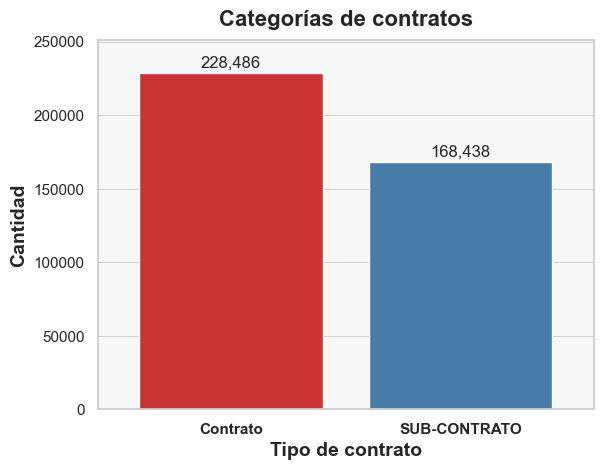

In [18]:
ax = sns.countplot(df, 
              x='Categoría',
              palette = "Set1")

ax.set_title('Categorías de contratos',fontsize = 16, fontweight = 'bold', pad = 10)
ax.set_xlabel('Tipo de contrato',fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Cantidad',fontsize = 14, fontweight = 'bold' )
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding = 2)
ax.set_xticklabels(['Contrato','SUB-CONTRATO'], fontweight = 'bold')
ax.margins(0.10)
plt.show()

# Análisis de variables continuas 

## Resumen estadístico

In [19]:
df['Ocupados'].describe()

count    396924.000000
mean          8.761221
std          40.008041
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max        3643.000000
Name: Ocupados, dtype: float64

## Análisis de distribución de valores continuos ('Ocupados')

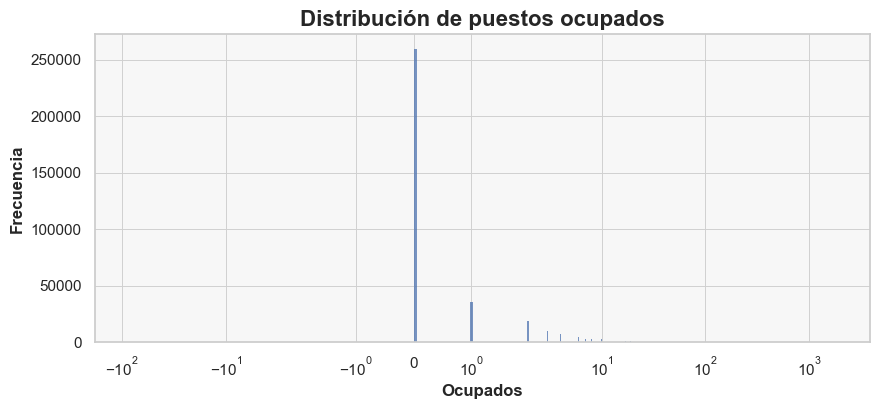

In [20]:
fig, axes = plt.subplots(figsize = (10,4) )

ax = sns.histplot(df, x = 'Ocupados')
ax.set_title('Distribución de puestos ocupados', fontsize = 16, fontweight = 'bold')
ax.set_ylabel('Frecuencia', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('Ocupados', fontsize = 12, fontweight = 'bold')
ax.set_xscale('symlog')
plt.show()

## Análisis de Outliers

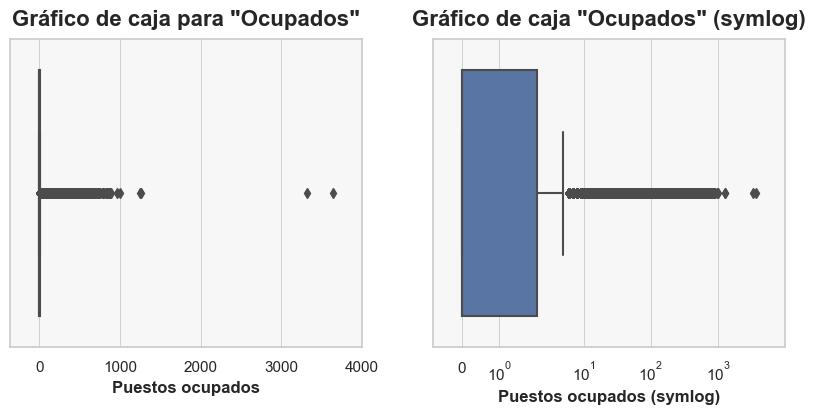

In [21]:
fig, axes = plt.subplots(
    nrows = 1, ncols = 2,
    figsize = (10,4),
    sharey = False)

sns.boxplot(df, x = 'Ocupados', ax = axes[0])
axes[0].set_title('Gráfico de caja para "Ocupados"', fontsize = 16, fontweight = 'bold', pad = 10)
axes[0].set_xlabel('Puestos ocupados', fontweight = 'bold', fontsize = 12)
sns.boxplot(df, x = 'Ocupados', ax = axes[1])
axes[1].set_title('Gráfico de caja "Ocupados" (symlog)', fontsize = 16, fontweight = 'bold', pad = 10)
axes[1].set_xlabel('Puestos ocupados (symlog)', fontweight = 'bold', fontsize = 12)
axes[1].set_xscale('symlog')
axes[0].margins(0.1)
axes[1].margins(0.1)
plt.show()

##  Verificar a qué función corresponden los casos donde hay más de 3000 puestos ocupados (outliers)

In [22]:
df_2 = df[df['Ocupados']>3000]
df_2

,AÑO,NUI,Región,Trimestre,Mes,Categoría,Función,Género,Ocupados,CLASE_INDUSTRIA_II,EXPLICACIÓN_CLASE_INDUSTRIA,COMEN
34282,2010,11229,10,1,enero,CONTRATO,Productivos_Directos,hombres,3317,HUMANO,NaN,Valores originales
37780,2010,14839,8,4,noviembre,CONTRATO,Productivos_Directos,mujeres,3643,HUMANO,NaN,Valores originales


## Verificar cómo es la distribución de puestos ocupados para productivos_directos

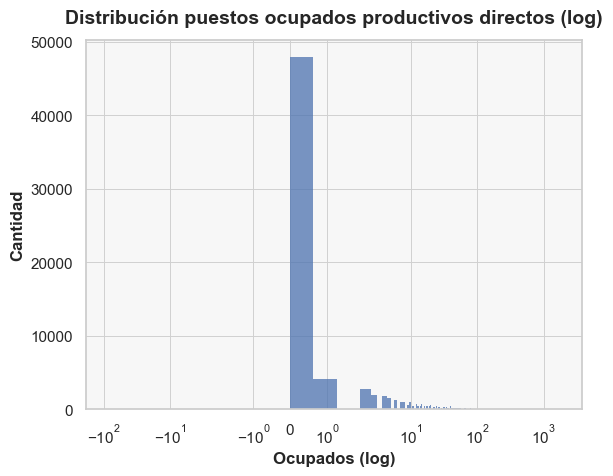

In [23]:
dist_productivos = df[df['Función']=='Productivos_Directos']

ax = sns.histplot(dist_productivos, x = 'Ocupados')
ax.set_title('Distribución puestos ocupados productivos directos (log)',fontsize = 14, fontweight = 'bold', pad = 12)
ax.set_xlabel('Ocupados (log)', fontweight = 'bold', fontsize = 12)
ax.set_ylabel('Cantidad', fontweight = 'bold', fontsize = 12)
ax.set_xscale('symlog')
plt.show()

## Resumen estadístico de puestos ocupados para productivos_directos

In [24]:
dist_productivos['Ocupados'].describe()

count    89466.000000
mean        26.853084
std         73.779049
min          0.000000
25%          0.000000
50%          0.000000
75%         14.000000
max       3643.000000
Name: Ocupados, dtype: float64

## Resumen estadístico para  puestos ocupados para el año 2010 

In [25]:
ocupados_2010 = df[df['AÑO']==2010]
ocupados_2010['Ocupados'].describe()

count    62424.000000
mean         6.535627
std         36.089263
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       3643.000000
Name: Ocupados, dtype: float64

## Conclusiones análisis de variables continuas

- La mayoría de valores se concentra cerca del 0, por lo que es difícil ver una clara distribución.
- Hay dos valores del 2010 que tienen más de 3.000 puestos ocupados, pero no se presentan más casos similares, 
  es probable que sean outliers.
- Para manejar los outliers se considerarán dos opciones, eliminar los valores > 3.000.
- Realizar discretización de la variable tanto por frecuencia, como por ancho del intérvalo.

## Análisis de variables categóricas 

### Análisis de variable función 

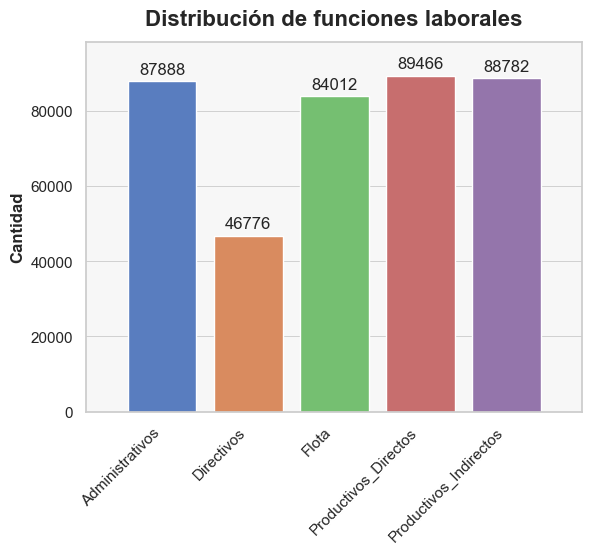

In [26]:
agrupacion_funcion = df.groupby('Función')['Función'].count().reset_index(name='Cantidad')
agrupacion_funcion

ax = sns.barplot(agrupacion_funcion, x = 'Función', y = 'Cantidad', palette = 'muted')
ax.set_title('Distribución de funciones laborales', fontweight = 'bold', fontsize = 16, pad = 12)
ax.set_xlabel(None)
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.bar_label(ax.containers[0], padding = 3)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = 'right')
ax.margins(0.1)
plt.show()

### Conclusiones variable función
- No hay una alta cardinalidad en esta variable, ya que solo contiene 5 clases distintas.
- No hay presencia de etiquetas raras ya que todas se encuentran en una gran proporción.

### Análisis de la variable Región

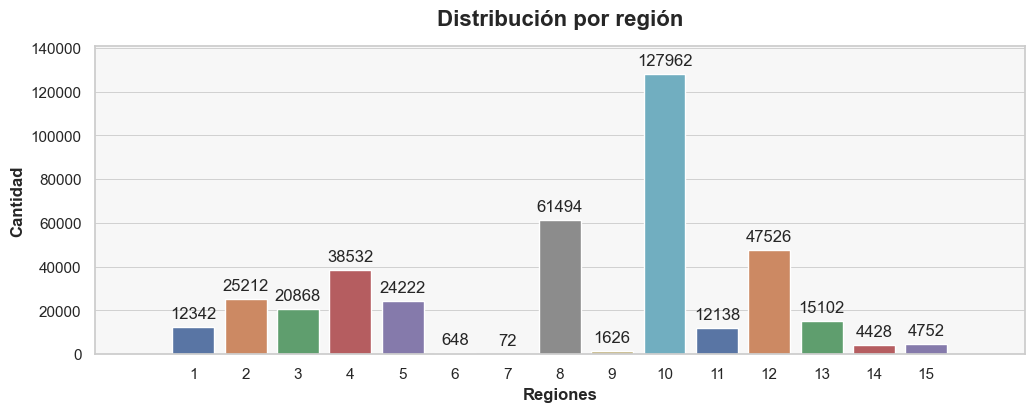

In [27]:
agrupacion_region = df['Región'].value_counts().reset_index(name = 'Cantidad')

fig, axes = plt.subplots(figsize = (12,4)) 
ax = sns.barplot(data = agrupacion_region, x = 'Región', y = 'Cantidad', palette = 'deep')
ax.set_title('Distribución por región', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel('Regiones', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.bar_label(ax.containers[0], padding = 4)
ax.margins(0.1)
plt.show()

### Conclusión variable región
- Predomina fuertemente la décima región en la data, se ve que la séptima, sexta y novena región tienen una precencia muy pequeña

### Análisis de variable género

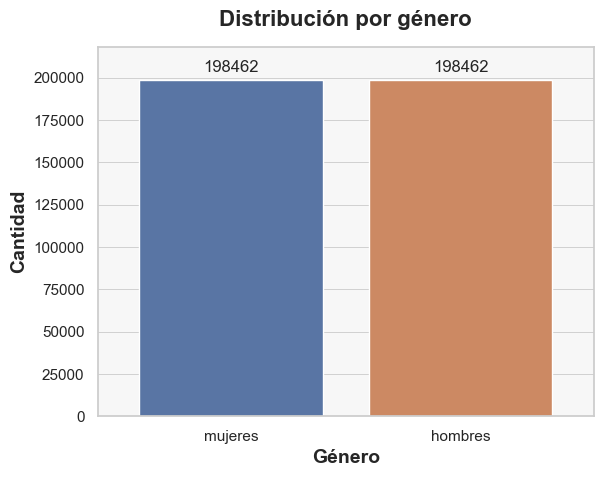

In [28]:
agrupacion_genero = df['Género'].value_counts().reset_index(name = 'Cantidad')

ax = sns.barplot(agrupacion_genero, x = 'Género', y = 'Cantidad', palette = 'deep')
ax.set_title('Distribución por género', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel('Género', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Cantidad', fontsize = 14, fontweight = 'bold')
ax.bar_label(ax.containers[0], padding = 4)
ax.margins(0.1)
plt.show()

### Conclusiones variable género 
- La cantidad de hombres y mujeres se encuentran en la misma proporción por lo que no hay alta cardinalidad, ni etiquetas raras.

### Análisis Clase de industria 

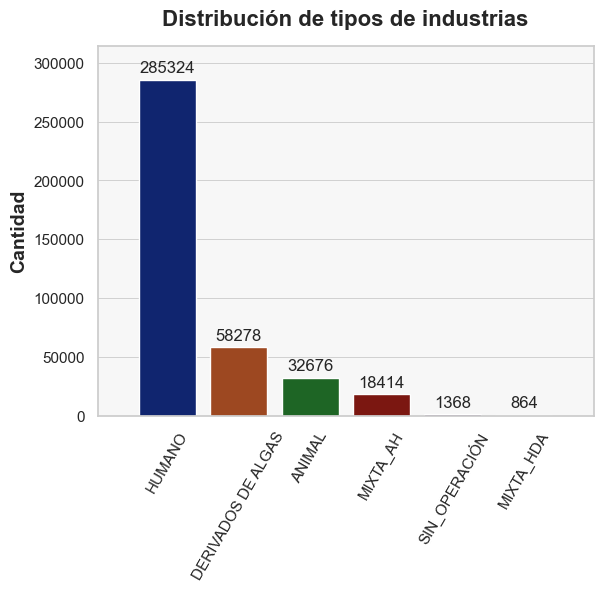

In [29]:
agrupacion_clase_industria = (df['CLASE_INDUSTRIA_II'].value_counts().rename_axis('Industria').reset_index(name = 'Cantidad'))

ax = sns.barplot(agrupacion_clase_industria, x = 'Industria', y = 'Cantidad', palette = 'dark')
ax.set_title('Distribución de tipos de industrias', fontweight = 'bold', fontsize = 16, pad = 15)
ax.set_xlabel(None)
ax.set_ylabel('Cantidad', fontweight = 'bold', fontsize = 14)
ax.bar_label(ax.containers[0], padding = 3)
ax.margins(0.1)
ax.set_xticklabels(ax.get_xticklabels(),rotation = 60)
plt.show()

### Conclusiones Clase de industria
- De acuerdo al análisis gráfico podría considerarse que las industrias del tipo humano tienen la mayor presencia.
- Puede ser necesario juntar las clases con menor presencia en una nueva clase para evitar etiquetas raras.

## Análisis bivariado

### Análisis de puestos ocupados por tipo de contrato

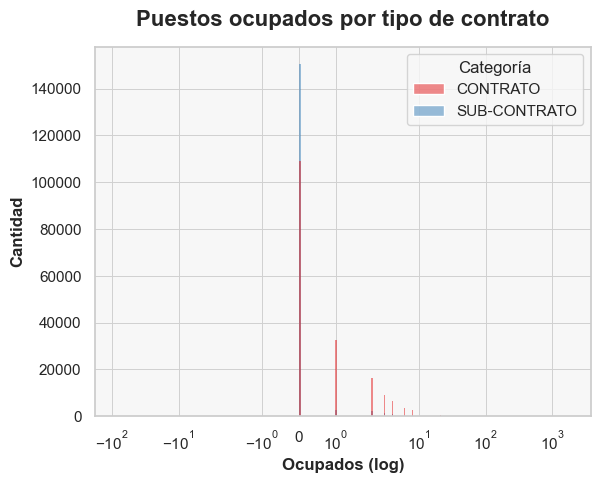

In [30]:
ax = sns.histplot(df, x = 'Ocupados', hue = 'Categoría', palette = 'Set1')
ax.set_title('Puestos ocupados por tipo de contrato', fontweight = 'bold', fontsize = 16, pad = 15)
ax.set_xlabel('Ocupados (log)', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Cantidad', fontweight = 'bold', fontsize = 12)
ax.set_xscale('symlog')
plt.show()

### Análisis de función por tipo de contrato 

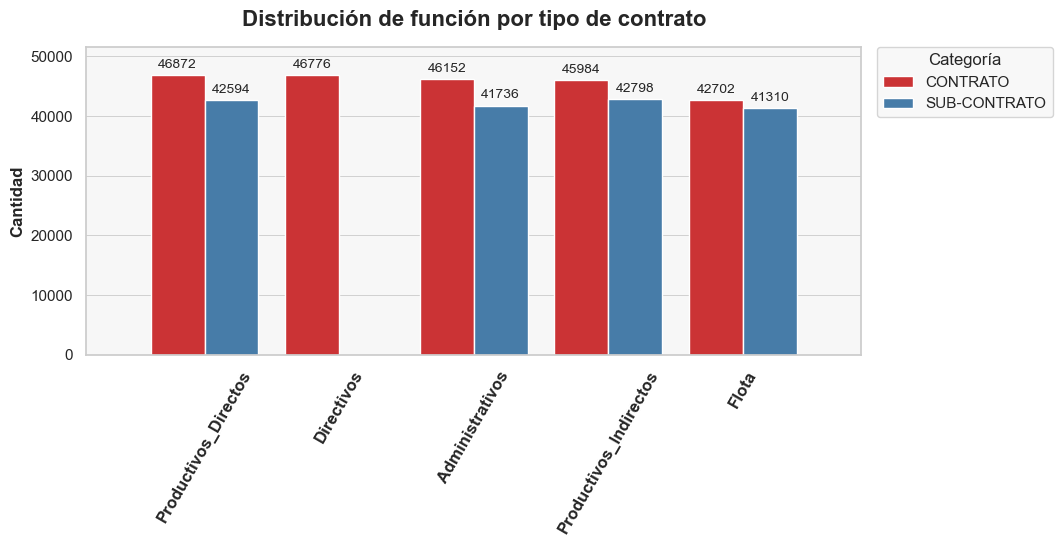

In [31]:
agrupacion_funcion_contrato = df.value_counts(['Función','Categoría']).reset_index(name = 'Cantidad')

fig, axes = plt.subplots(figsize = (10,4))

ax = sns.barplot(agrupacion_funcion_contrato, x = 'Función', y = 'Cantidad', hue = 'Categoría', palette = 'Set1')

# Etiquetas de las barras

for cont in ax.containers:
    ax.bar_label(cont, padding = 3, fontsize = 10)


ax.set_title('Distribución de función por tipo de contrato', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel(None)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 60, fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.margins(0.1)
ax.legend(title = 'Categoría', bbox_to_anchor =(1.02,1), loc = 'upper left', borderaxespad = 0)
plt.show()

### Conclusiones función - por tipo de contrato
- Todos los directivos están contratados, no hay ningún sub-contrato.
- La mayoría de personas son contratados.

### Análisis de región por tipo de contrato

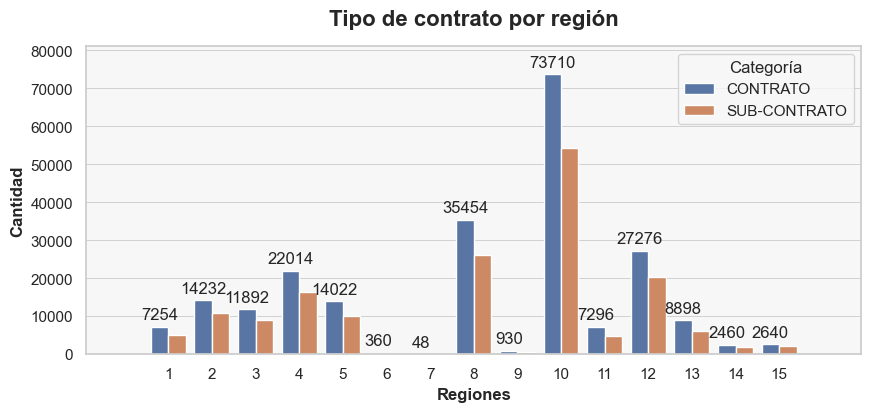

In [32]:
# Agrupación de regiones para gráficos

agrupacion_region_contrato = df.value_counts(['Región','Categoría']).reset_index(name = 'Cantidad')

fig, axes = plt.subplots(figsize = (10,4))
ax = sns.barplot(data = agrupacion_region_contrato, x = 'Región', y = 'Cantidad', hue ='Categoría', palette = 'deep')
ax.set_title('Tipo de contrato por región', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel('Regiones', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.bar_label(ax.containers[0], padding = 3)
ax.margins(0.1)
plt.show()

### Análisis de género por tipo de contrato

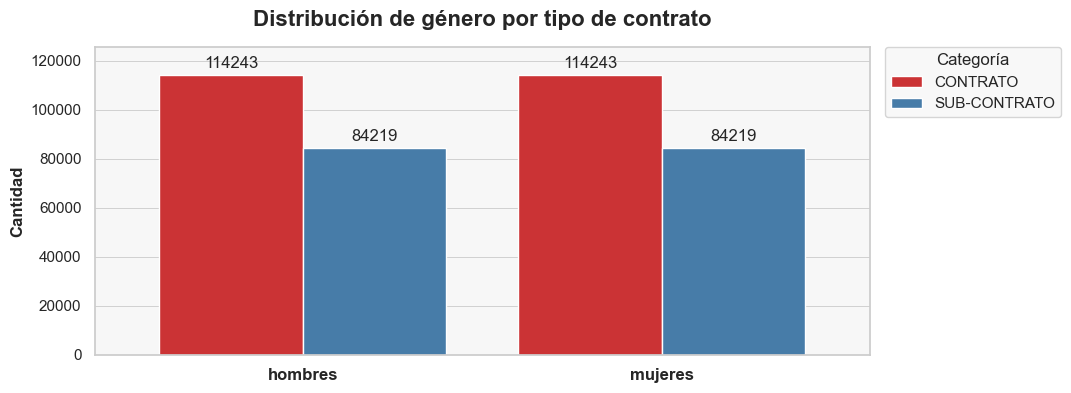

In [33]:
agrupacion_genero_contrato = df.value_counts(['Género','Categoría']).reset_index(name = 'Cantidad')

fig, axes = plt.subplots(figsize = (10,4))
ax = sns.barplot(data = agrupacion_genero_contrato, x = 'Género', y = 'Cantidad', hue = 'Categoría', palette = 'Set1')

for cont in ax.containers:
    ax.bar_label(cont, padding = 3)

ax.set_title('Distribución de género por tipo de contrato', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel(None)
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.set_xticklabels(ax.get_xticklabels(), fontweight = 'bold', fontsize = 12)
ax. margins(0.1)
ax.legend(title = 'Categoría', bbox_to_anchor = (1.02, 1), loc = 'upper left', borderaxespad = 0)

plt.show()

### Conclusiones tipo de contrato por género 
- La mayoría son personas contratadas en ambos géneros.
- Existe la misma cantidad de hombres y mujeres en ambas categorías, probablemente hay una política de equidad en ese sector.

### Análisis de tipo de industria por tipo de contrato 

In [34]:
df.columns

Index(['AÑO', 'NUI', 'Región', 'Trimestre', 'Mes', 'Categoría', 'Función',
       'Género', 'Ocupados', 'CLASE_INDUSTRIA_II',
       'EXPLICACIÓN_CLASE_INDUSTRIA', 'COMEN'],
      dtype='object')

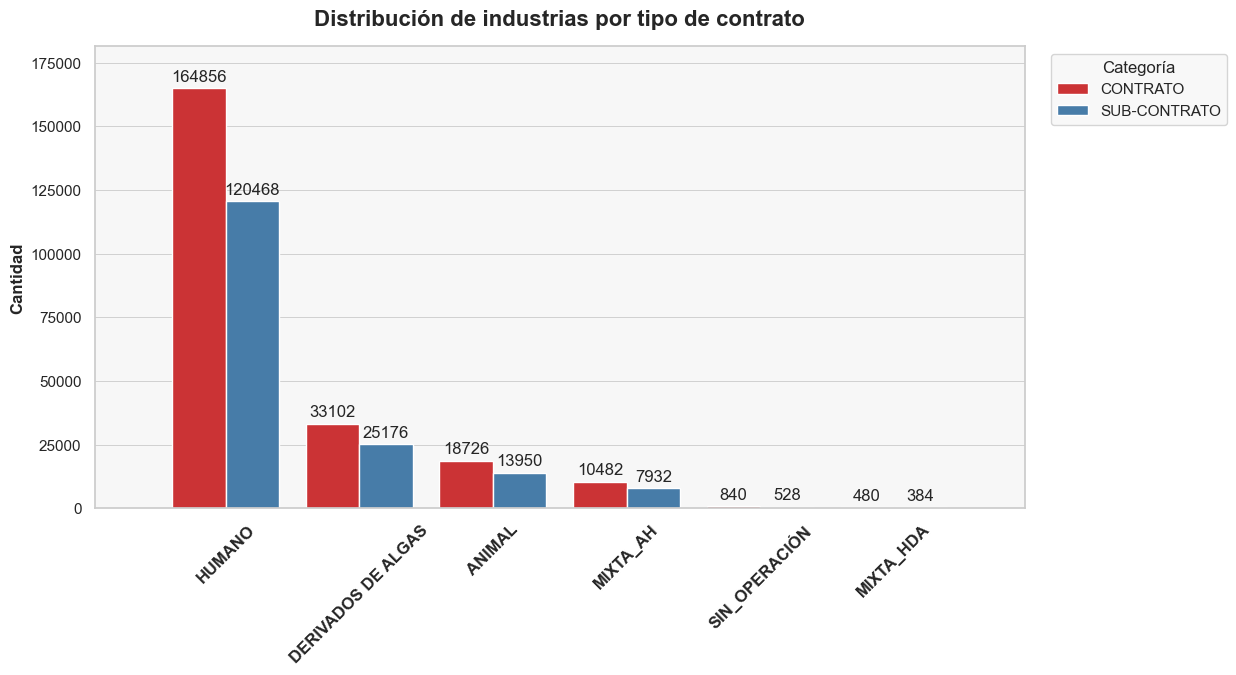

In [35]:
agrupacion_industria_contrato = df.value_counts(['CLASE_INDUSTRIA_II', 'Categoría']).rename_axis(['Industria','Categoría']).reset_index(name = 'Cantidad')

fig, axes = plt.subplots(figsize = (12, 6))

ax = sns.barplot(data = agrupacion_industria_contrato, x = 'Industria', y = 'Cantidad', hue = 'Categoría', palette = 'Set1')

for cont in ax.containers:
    ax.bar_label(cont, padding = 3)

ax.set_title('Distribución de industrias por tipo de contrato', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel(None)
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 12, fontweight = 'bold', rotation = 45)
ax.margins(0.1)
ax.legend(title = 'Categoría', bbox_to_anchor = (1.02, 1), loc = 'upper left')
plt.show()

### Conclusiones tipo de industria - contrato
- En todas las industrías la mayoría de personas son contratados

### Análisis temporal 

### Contratos por años

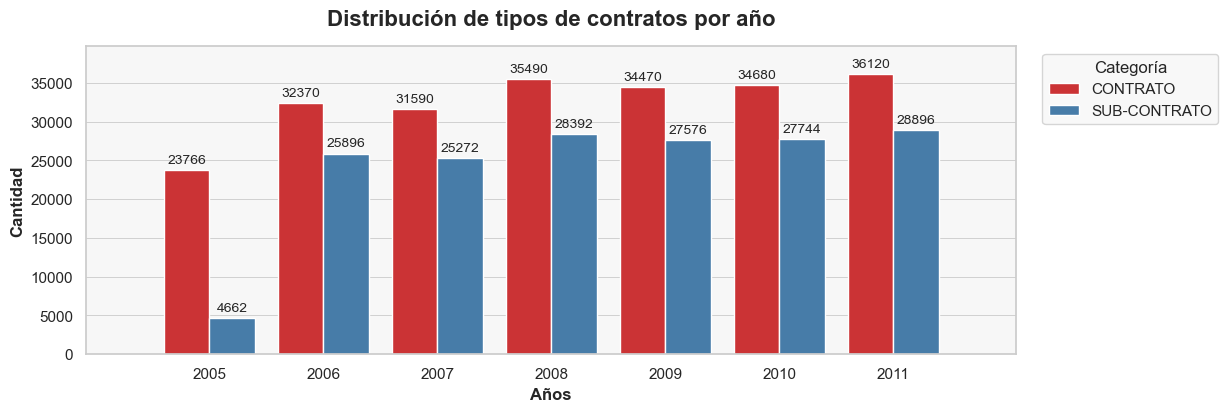

In [36]:
agrupacion_año_contratos = df.value_counts(['AÑO','Categoría']).reset_index(name = 'Cantidad')


fig, axes = plt.subplots(figsize = (12,4))
ax = sns.barplot(data = agrupacion_año_contratos, x = 'AÑO', y = 'Cantidad', hue = 'Categoría', palette = 'Set1')

for cont in ax.containers:
    ax.bar_label(cont, padding = 3, fontsize = 10)

ax.set_title('Distribución de tipos de contratos por año', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel('Años', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.margins(0.1)
ax.legend(title = 'Categoría',bbox_to_anchor = (1.02, 1), loc = 'upper left')
plt.show()

### Conclusiones de contratos por años 
- Desde el 2006 aumentó consideralmente la cantidad de personas que trabajaban.
- Desde 2006 aumentó mucho la cantidad de personas que sub-contratan.

### Análisis de contratos por trimestre

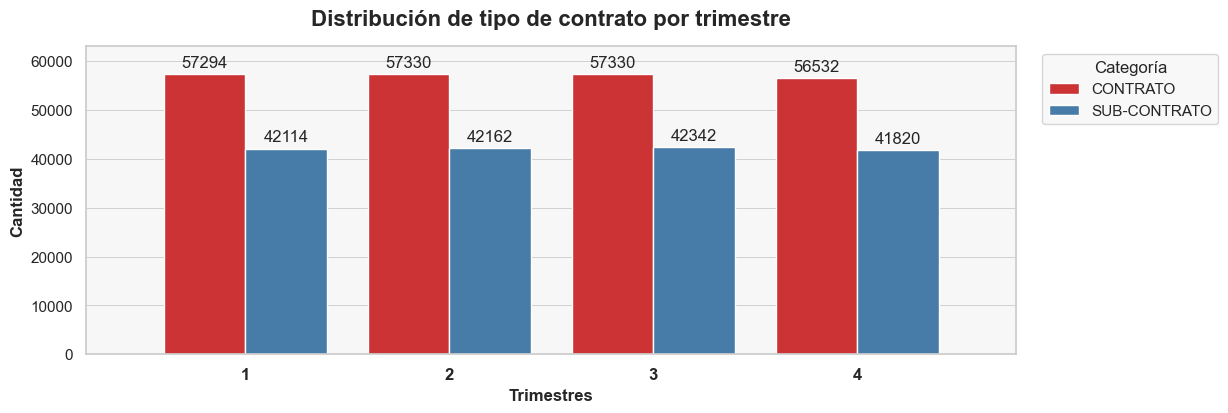

In [37]:
agrupacion_trimestre_contratos = df.value_counts(['Trimestre','Categoría']).reset_index(name='Cantidad')

fig, axes = plt.subplots(figsize = (12, 4))

ax = sns.barplot(data = agrupacion_trimestre_contratos, x = 'Trimestre', y = 'Cantidad', hue = 'Categoría', palette = 'Set1')

for cont in ax.containers:
    ax.bar_label(cont, padding = 3)
    
ax.set_title('Distribución de tipo de contrato por trimestre', fontsize = 16, fontweight = 'bold', pad = 15)
ax.set_xlabel('Trimestres', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Cantidad', fontsize = 12, fontweight = 'bold')
ax.margins(0.1)
ax.legend(title = 'Categoría',bbox_to_anchor = (1.02, 1), loc = 'upper left' )
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 12, fontweight = 'bold')

plt.show()

### Conclusiones de contratos por trimestre
- No se aprecia ninguna diferencia significativa entre los contratos de cada trimestre

### Análisis de puestos promedio ocupados por año 

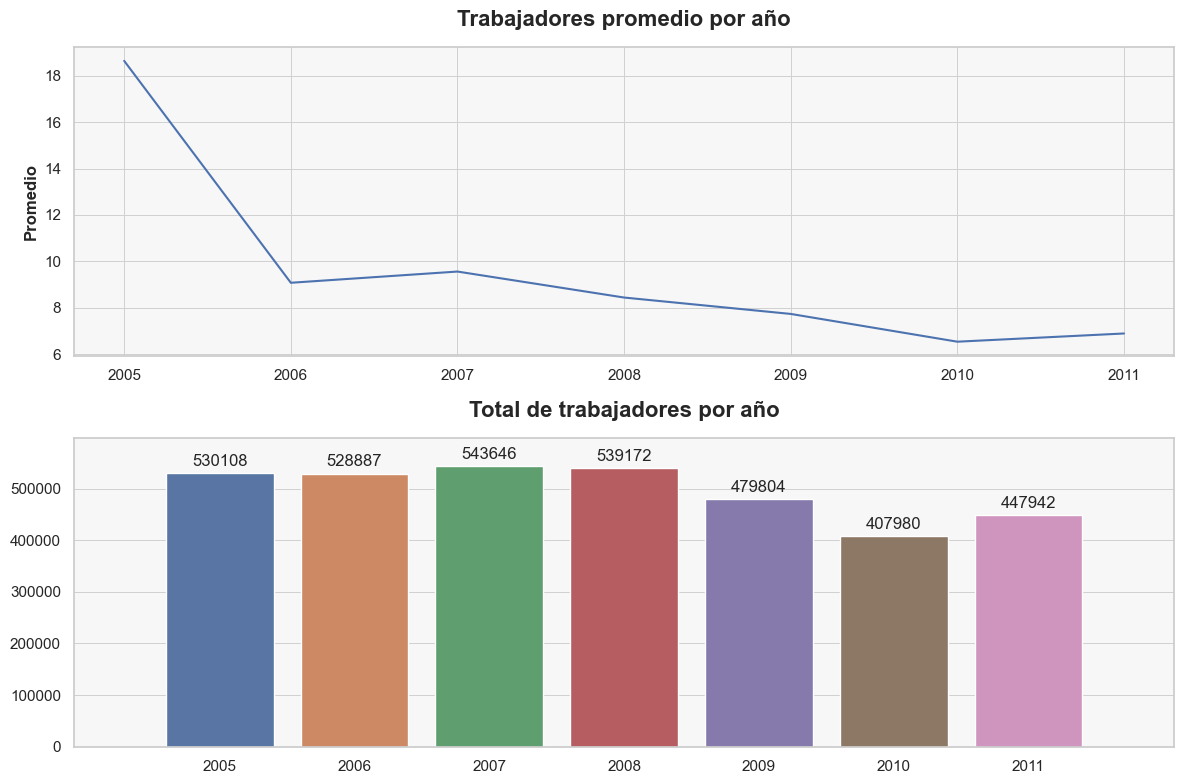

In [38]:
resumen_año_ocupados = df.groupby('AÑO')['Ocupados'].agg(promedio = 'mean', total = 'sum').reset_index()

fig, axes = plt.subplots(nrows = 2, ncols = 1,figsize = (12, 8))

sns.lineplot(data = resumen_año_ocupados, x = 'AÑO', y = 'promedio', ax = axes[0])

axes[0].set_title('Trabajadores promedio por año', fontsize = 16, fontweight = 'bold', pad = 15)
axes[0].set_xlabel(None)
axes[0].set_ylabel('Promedio', fontsize = 12, fontweight = 'bold')


sns.barplot(data = resumen_año_ocupados, x = 'AÑO', y = 'total', ax = axes[1])

for cont in axes[1].containers:
    axes[1].bar_label(cont, padding = 3)

axes[1].set_title('Total de trabajadores por año', fontsize = 16, fontweight = 'bold', pad = 15)
axes[1].set_xlabel(None)
axes[1].set_ylabel(None)
axes[1].margins(0.1)

plt.tight_layout()
plt.show()


### Conclusiones de trabajadores por año 
- Se ve una disminución en la cantidad de trabajadores promedio, siendo el 2005 la más alta.
- Se ve que para el año 2011 ha disminuido significativamente la cantidad de trabajadores, esto puede ser debido a automatización de procesos.

## Conclusiones clave (resumen ejecutivo)

**Hallazgos principales**
- La variable **`Ocupados`** está **altamente sesgada** hacia 0, con **cola larga** y pocos valores muy altos (outliers), especialmente en funciones productivas.
- Se detectaron **inconsistencias de texto** (espacios/variantes) en variables categóricas que ya fueron normalizadas para asegurar análisis consistente.
- En el **tiempo** (AÑO/Trimestre/Mes) se observan cambios de nivel que justifican comparar **promedios** vs **totales** anuales.

**Decisiones para el análisis y modelado**
- **Eliminar las columnas con nulos**, debido a que representan más de un 80% de valores nulos.
- **Conservar los outliers** de `Ocupados` y **discretizar** la variable en **bins**. Esto “absorbe” valores extremos y mejora la legibilidad sin perder trazabilidad.
- Mantener **dos representaciones**: `Ocupados` cruda (continua) y `Ocupados_bin` (ordinal) para contrastar enfoques de modelado.
- **Estratificar** los splits de entrenamiento/validación por `Categoría` y, si aplica, usar **división temporal** (por año) para evitar fuga de información.
- Codificación de categóricas según el modelo: **One‑Hot** / **Target Encoding**; decidir tras verificar cardinalidad y impacto.

**Próximos pasos**
- Exportar dataset limpio (normalizado y con bins) a `data/processed/…`.
- Validar estabilidad de los **bins** definidos (fijar límites con el *train* y reutilizarlos en *test*).
- Comparar baseline con `Ocupados` continua vs `Ocupados_bin` y evaluar métricas estratificadas por `Categoría`.

### Eliminar columnas con outliers

In [39]:
df_final = df.drop(columns = ['NUI', 'EXPLICACIÓN_CLASE_INDUSTRIA','COMEN'] )

### Transformar el dataframe a csv 

In [40]:
df_final.to_csv('data/processed_eda/contratos_clean.csv', sep = ',', encoding =  'utf-8', index = False)